In [1]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv(r'/content/drive/MyDrive/datasets/retail_sales_dataset.csv')
df.head()

Mounted at /content/drive


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


Data Cleaning

In [2]:
df.info()
df.isnull().sum()
df=df.dropna()
df=df.drop_duplicates()
df['Date']=pd.to_datetime(df['Date'])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


Descriptive Statistics

In [3]:
df.describe()
print("Mean:\n", df.mean(numeric_only=True))
print("Median:\n",df.median(numeric_only=True))
print("Mode:",df.mode().iloc[0])
print("Std Dev:\n",df.std(numeric_only=True))

Mean:
 Transaction ID    500.500
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64
Median:
 Transaction ID    500.5
Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64
Mode: Transaction ID                        1
Date                2023-05-16 00:00:00
Customer ID                     CUST001
Gender                           Female
Age                                43.0
Product Category               Clothing
Quantity                            4.0
Price per Unit                     50.0
Total Amount                       50.0
Name: 0, dtype: object
Std Dev:
 Transaction ID    288.819436
Age                13.681430
Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64


Time Series Analysis

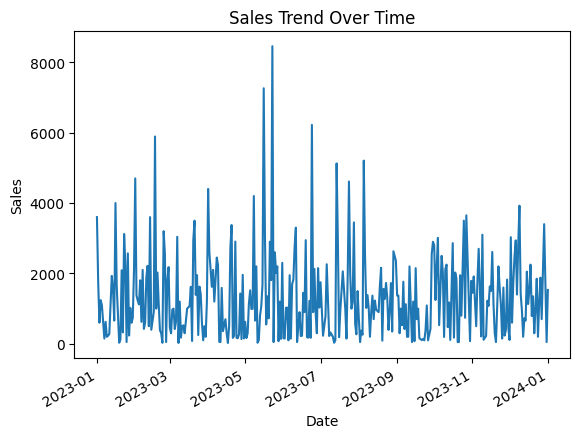

In [7]:
sales_trend=df.groupby('Date')['Total Amount'].sum()

import matplotlib.pyplot as plt

plt.figure()
sales_trend.plot()
plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

customer & Product Analysis

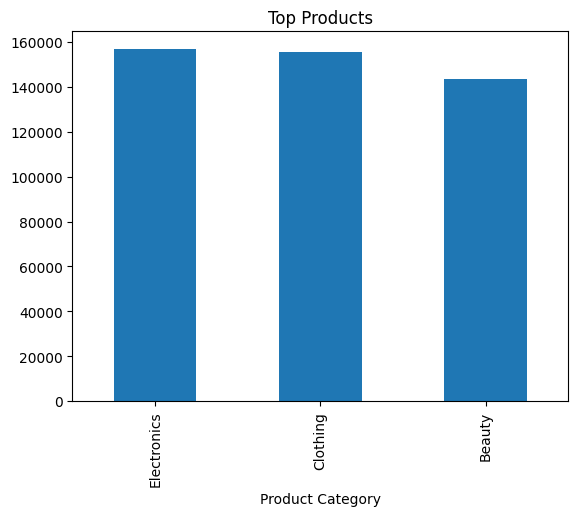

In [9]:
top_products=df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)
top_products.head(10).plot(kind='bar')
plt.title("Top Products")
plt.show()

customer Behavior

In [11]:
customer_sales = df.groupby('Customer ID')['Total Amount'].sum()
customer_sales.describe()

,Total Amount
count,1000.000000
mean,456.000000
std,559.997632
min,25.000000
25%,60.000000
50%,135.000000
75%,900.000000
max,2000.000000


Demographics

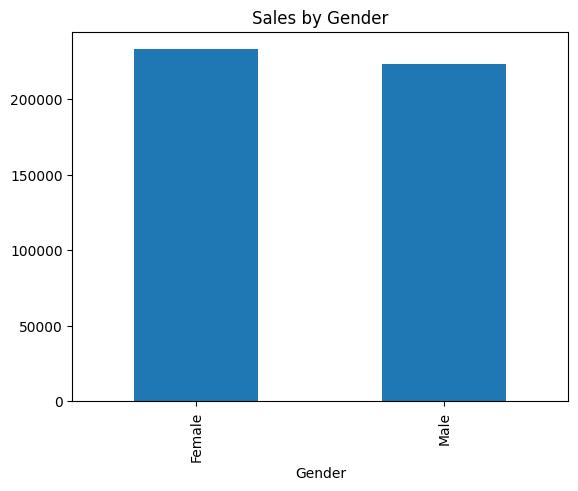

In [13]:
df.groupby('Gender')['Total Amount'].sum().plot(kind='bar')
plt.title("Sales by Gender")
plt.show()

Heatmap

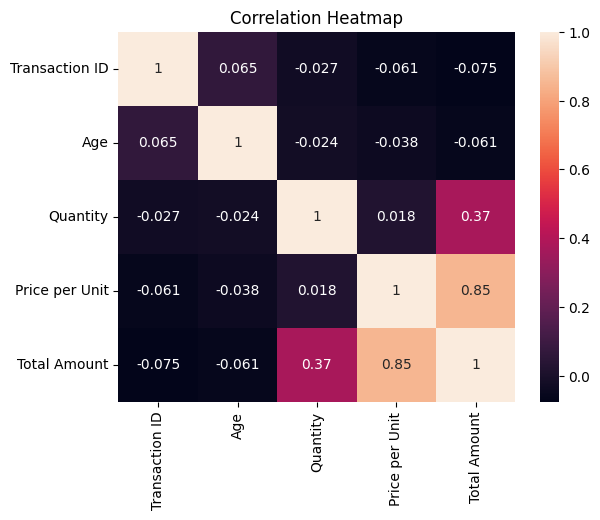

In [14]:
import seaborn as sns
plt.figure()
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.title("Correlation Heatmap")
plt.show()

Bar chart

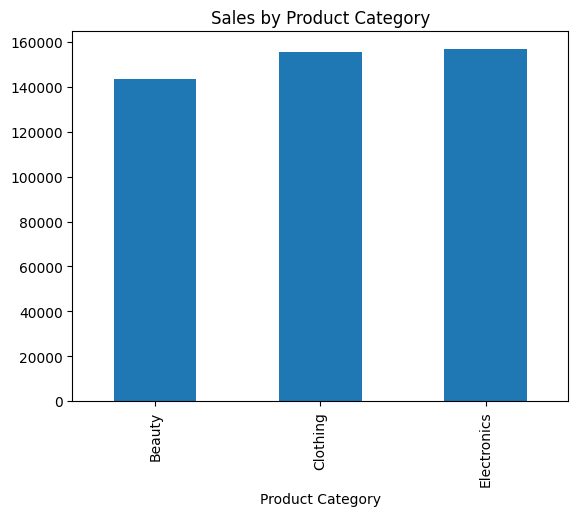

In [16]:
df.groupby('Product Category')['Total Amount'].sum().plot(kind='bar')
plt.title("Sales by Product Category")
plt.show()